Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.

В этом задании вам так же нужно будет **ЗАПОЛНИТЬ ПРОПУСКИ** и сделать так, чтобы все работало. Ну и, конечно, написать **ВЫВОДЫ**!!!
***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from tqdm.auto import tqdm
from nltk.tokenize import WordPunctTokenizer
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

c:\Users\pochi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Данные (1 pt)

В этом задании мы поработаем с чисто текстовыми данными, а именно **комментариями на YouTube** _(я искала русские датасеты, но там слишком много непотребщины, поэтому будем с английским работать)_. Про датасет можно почитать [тут](https://www.kaggle.com/datasets/surajbhandari527/100k-youtube-comments-youtube-sentiment-dataset).

In [2]:
df = pd.read_csv('100000 Youtube comments sentiment dataset.csv').dropna().reset_index(drop=True)
df = df[df['Sentiment'] != 'neutral']
print(df.shape)
df.sample(5)

(111796, 2)


,Comment,Sentiment
20211,None of their dads could beat Andrew in a fight,Negative
71727,Ppl who hate James Charles before this\n👇🏻,Negative
37461,*heavy sigh before apology videos*,Positive
5259,This makes me like Tate actually 😅,Positive
87449,World class engineers don't do this shit. It's...,Negative


В наших данных всего лишь **2 столбца**. Нетрудно догадаться, что мы займемся задачей **классификации комментариев** на негативные и позитивные. Мы не будем использовать какие-то продвинутые методы, будем просто использовать статистики по токенам.

Важно, что задача анализа текстов — это не всегда про классификацию, но и про статистики, зависимости и все такое. Иногда важно **анализировать тексты и для поиска паттернов или зависимостей**.

***

Сначала заменим `'Positive'` на `0`, `'Negative'` на `1` для удобства работы.

In [3]:
df['label'] = df['Sentiment'].map({'Positive': 1, 'Negative': 0})
df.sample(5)

,Comment,Sentiment,label
32815,First guy at valve that watched this was proba...,Positive,1
54517,I feel do bad I wish I was there to comfort her😢,Positive,1
85819,Smart move by apple. They tried to force those...,Positive,1
94648,27:48 the guy w the whip cream with the gloves...,Positive,1
66350,Ppl who want to be kenzies bestie\n👇🏾,Positive,1


Также нам важно посмотреть на **баланс классов**, а то вдруг оны несбалансированны и надо думать, что делать...

In [4]:
df['Sentiment'].value_counts(normalize=True)

Sentiment
Negative    0.500054
Positive    0.499946
Name: proportion, dtype: float64

_Ну как, сбалансированны ли данные?_

Теперь еще немного проанализируем данные: посмотрим на **длину текстов**. Это может быть очень важно для понимания: какие токенизаторы использовать, разделяются ли классы по длине.

Max 5487, Min 3, Mean 99.0685534366167


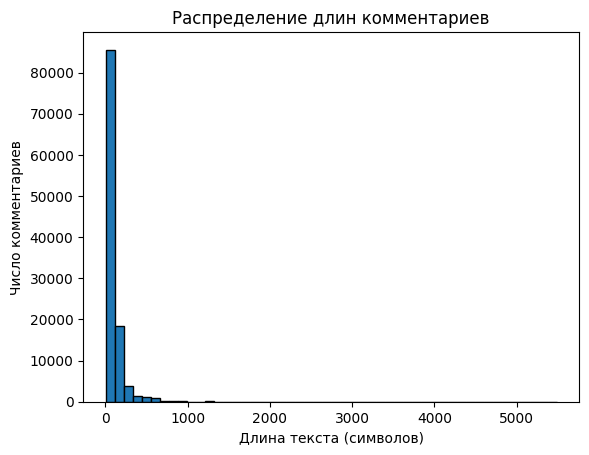

In [5]:
# длина всех текстов
lens = df['Comment'].str.len()          
print(f"Max {lens.max()}, Min {lens.min()}, Mean {lens.mean()}")

# визуализация
plt.hist(lens, bins=50, edgecolor='black')
plt.xlabel('Длина текста (символов)')
plt.ylabel('Число комментариев')
plt.title('Распределение длин комментариев')
plt.show()

Positive: Max 5487, Min 3, Mean 107.04499749516926
Negative: Max 3775, Min 4, Mean 91.09382155123068


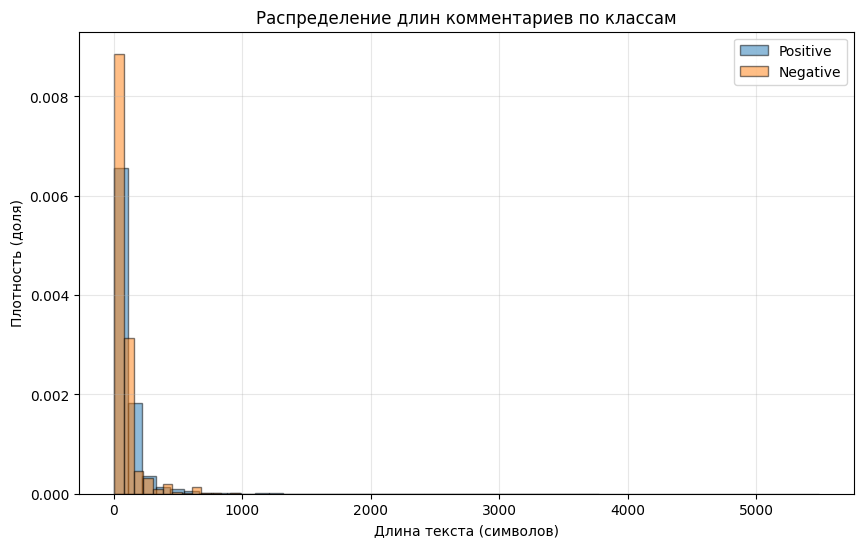

In [6]:
# длина текстов по классам
lens_pos = df[df['Sentiment'] == 'Positive']['Comment'].str.len()
print(f"Positive: Max {lens_pos.max()}, Min {lens_pos.min()}, Mean {lens_pos.mean()}")

lens_neg = df[df['Sentiment'] == 'Negative']['Comment'].str.len()
print(f"Negative: Max {lens_neg.max()}, Min {lens_neg.min()}, Mean {lens_neg.mean()}")

# визуализация
plt.figure(figsize=(10, 6))
plt.hist(lens_pos, bins=50, alpha=0.5, density=True, label='Positive', edgecolor='black')
plt.hist(lens_neg, bins=50, alpha=0.5, density=True, label='Negative', edgecolor='black')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('Длина текста (символов)')
plt.ylabel('Плотность (доля)')
plt.title('Распределение длин комментариев по классам')
plt.show()

In [7]:
print(f"Median all: {lens.median()}")

print(f"Median positive: {lens_pos.median()}")

print(f"Median negative: {lens_neg.median()}")

Median all: 67.0
Median positive: 75.0
Median negative: 61.0


**ПАРУ СЛОВ О ТОМ, ЧТО ВЫ ПОНЯЛИ ИЗ ЭТОГО**

1. классы хорошо сбалансирвоаны: практически 50 на 50.
2. длина очень сильно варьруется, в каждом классе примерно от 3 символов до 5500. медиана в классах и в общем и целом от 60 до 75 символов.
3. по гитограмме видно, что больше всего коротких комментариев 50-100 символов. 

Ну а теперь подробнее посмотрим на примеры комментариев и перейдем к токенизации

In [8]:
pos_ex = list(df[df['Sentiment'] == 'Positive'].sample(5)["Comment"])
neg_ex = list(df[df['Sentiment'] == 'Negative'].sample(5)["Comment"])

print("Positive:")
for ex in pos_ex:
    print(ex)

print("\nNegative:")
for ex in neg_ex:
    print(ex)

Positive:
You might be referencing an ole fashioned “Cleveland Steamer” when you mentioned “a nice steaming load on another person’s chest.” @0:13
People that think that Kenzie
  deserve better
👇
This is relevant to xqc currently. I imagine gambling sites team with youtubers and streamers and give them either free digital currency to play on their sites, or change thier odds to produce the illusion that people could win
The way she looks at them when their hugging 🥺🥺🥺
I feel so bad for her she Doesn’t deserve to be treated like that she is so pretty

Negative:
👇🏻People that now 
hate James Charles
our boy felix lost a cat ear in the war...
People who hated his ass in the first place- raise your hand ✋
Edit- why the hell has this got 430 likes-
I hate the fact that after she says she gets bullied a lot, he continues to bully her.
Well now James Charles in my mind is a rude baddie


# Токенизация (4 pt)

**Токенизация** — это процесс **разбиения текста на меньшие единицы** (токены), которые могут быть:
- Словами (word-level): ```"I love NLP" → ["I", "love", "NLP"]```
- Символами (char-level): ```"NLP" → ["N", "L", "P"]```
- Субсловами (subword-level, BPE): ```"unbelievable" → ["un", "believ", "able"]```

**Почему это важно?**

_Размер словаря:_  
**Word**: большой словарь, много редких слов  
**Char**: маленький словарь, но очень длинные последовательности  
**BPE**: компромисс 

_OOV проблема (Out-of-Vocabulary):_  
**Word** токенизация не знает новых слов  
**Char** и **BPE** могут работать с любыми словами

_Контекст задачи:_  
Для классификации тональности часто достаточно word-токенизации  
Для работы с опечатками, сленгом — BPE лучше

***

Мы попробуем **сравнить все эти три способа** для нашей задачи, но сначала давайте их реализуем.

Для начала разделим наш датасет на обучающую и тестовую выборку. Очевидно, что **анализировать** мы будем только **тестовую выборку**.

In [9]:
train_data, test_data = train_test_split(df, test_size=0.3, random_state=42, stratify=df['Sentiment'])
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)
print(train_data.shape)

(78257, 3)


### Word-level (0,5 pt)

Для разбиения на слова очень удобно использовать `WordPunctTokenizer` из библиотеки `nltk` (как понятно из названия, он разделяет на **слова и пунктуацию**). Давайте **разобьем комментарии на слова** и в тестовом и в обучающем наборах.

Понятно, что когда мы разбиваем на слова, для нас важен их смысл. Поэтому для того, чтобы убрать различие односмысловых токенов, написанных по-разному, **приведем все к нижнему регистру**.

In [10]:
tokenizer = WordPunctTokenizer()

# создайте столбец с токенами уровня слов
train_data['tokens_word'] = train_data['Comment'].str.lower().apply(tokenizer.tokenize)
test_data['tokens_word'] = test_data['Comment'].str.lower().apply(tokenizer.tokenize)

In [11]:
assert train_data['tokens_word'][666] == ['i', 'just', 'want', 'to', 'give', 'her', 'a', 'hug', '😭']
assert train_data['tokens_word'][101][1] == '’'
assert train_data['tokens_word'][42][-1] == '👇🏻'

assert test_data['tokens_word'][321] == ['she', 'needs', 'to', 'be', 'cared', 'by']
assert test_data['tokens_word'][666][10] == 'pathological'
assert test_data['tokens_word'][42][-1] == '😭'

In [12]:
train_data.sample(3)

,Comment,Sentiment,label,tokens_word
12291,This situation is like when a 9 year old tries...,Negative,0,"[this, situation, is, like, when, a, 9, year, ..."
6339,i love this i belong here keep it up simplilearn,Positive,1,"[i, love, this, i, belong, here, keep, it, up,..."
56502,always interesting to see how advanced we are ...,Positive,1,"[always, interesting, to, see, how, advanced, ..."


Давайте посчитаем **количество токенов** в этом случае

In [13]:
# посчитайте количество уникальных токенов
all_word_tokens = [token for tokens_list in train_data['tokens_word'] for token in tokens_list]
vocab_word_count = len(set(all_word_tokens))
vocab_word_count

25529

### Char-level (0,5 pt)

В этом случае можно вообще обойтись просто удобствами языка и просто **пройтись по элементам строки**. Давайте также создадим и столбец для такой токенизации.

Тут уже **не будем приводить к нижнему регистру**, так как смысл все равно не важен, а информацию потерять можем.

In [14]:
# создайте столбец с токенами уровня символов
train_data['tokens_char'] = train_data['Comment'].apply(list)
test_data['tokens_char'] = test_data['Comment'].apply(list)

In [15]:
assert len(train_data['tokens_char'][666]) == 30
assert train_data['tokens_char'][101][1] == 't'
assert train_data['tokens_char'][42][-1] == '🏻'

assert len(test_data['tokens_char'][321]) == 24
assert test_data['tokens_char'][666][10] == 'e'
assert test_data['tokens_char'][42][-1] == '😭'

И тут посчитаем **количество токенов**.

In [16]:
vocab_char_count = len(set(char for tokens in train_data['tokens_char'] for char in tokens))
vocab_char_count

791

### BPE, ну или что-то очень похожее (2,5 pt)

**Byte-Pair Encoding (BPE)** — алгоритм субсловной токенизации, который:
1. начинает с _посимвольного разбиения_,
2. итеративно _объединяет самые частые пары_ токенов,
3. останавливается при достижении _нужного размера словаря_.

Вам нужно самим реализовать такой токенайзер (упрощенную версию), заполнив пропуски.

In [17]:
class BPETokenizer:
    
    def __init__(self, vocab_size=1000):

        self.vocab_size = vocab_size
        self.vocab = {}  # токен -> индекс
        self.merges = {}  # список слияний (пара токенов -> новый токен)
        self._cache = {} # для ускорения токенизации
        
    def _get_stats(self, tokens):
        # посчитайте частоту каждой пары соседних токенов
        counts = defaultdict(int)
        for i in range(len(tokens) - 1):
            counts[(tokens[i], tokens[i+1])] += 1
        return counts

    def _merge(self, tokens, pair, new_token):
        # замените все вхождения пары на один новый токен
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(new_token)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        return new_tokens

    def train(self, text):
        # посчитайте частоту слов, разделяя их пробелами
        words = words = text.split()
        # представьте каждое слово как список символов с пробелом в конце
        word_freqs = Counter([" ".join(list(word)) + " </w>" for word in words])
        
        # создайте начальный словарь из уникальных символов
        unique_chars = set()
        for word in word_freqs:
            for char in word.split():
                unique_chars.add(char)
        
        self.vocab = {char: i for i, char in enumerate(sorted(list(unique_chars)))}
        num_merges = self.vocab_size - len(self.vocab)
    
        for i in tqdm(range(num_merges)):
            # посчитайте пары только внутри уникальных слов, умножая на их частоту
            pairs = defaultdict(int)
            for word, freq in word_freqs.items():
                symbols = word.split()
                for j in range(len(symbols) - 1):
                    pairs[(symbols[j], symbols[j+1])] += freq
            
            if not pairs:
                break
                
            best_pair = max(pairs, key=pairs.get)
            new_token = "".join(best_pair)
            
            self.merges[best_pair] = new_token
            self.vocab[new_token] = len(self.vocab)
            
            # обновите словарь частот слов (замена пары на новый токен)
            new_word_freqs = {}
            pair_str = " ".join(best_pair)      # "a b"
            replacement = new_token             # "ab"
            for word, freq in word_freqs.items():
                new_word = word.replace(pair_str, replacement)
                new_word_freqs[new_word] = freq
            word_freqs = new_word_freqs

    def tokenize(self, text):
        words = text.split()
        result = []
        
        for word in words:
            if word not in self._cache:
                word_tokens = list(word) + ["</w>"]
                for pair, new_token in self.merges.items():
                    word_tokens = self._merge(word_tokens, pair, new_token)
                self._cache[word] = word_tokens
            
            result.extend(self._cache[word])
            
        return result

Применим эту токенизацию также как и прошлые

In [18]:
bpe_tokenizer = BPETokenizer(vocab_size=5000)
full_text = " ".join(train_data['Comment'].astype(str).str.lower())
bpe_tokenizer.train(full_text)

train_data['tokens_bpe'] = [bpe_tokenizer.tokenize(x.lower()) for x in tqdm(train_data['Comment'])]
test_data['tokens_bpe'] = [bpe_tokenizer.tokenize(x.lower()) for x in tqdm(test_data['Comment'])]

100%|██████████| 33539/33539 [00:42<00:00, 796.14it/s] 


In [19]:
assert train_data['tokens_bpe'][4] == ['i</w>', 'miss</w>', 'pri', 'me</w>', 'h3h3</w>']
assert train_data['tokens_bpe'][101][1] == 'wi'
assert train_data['tokens_bpe'][42][-1] == '👇🏻</w>'

assert test_data['tokens_bpe'][2] == ['kenzie</w>', 'won</w>', '🥇</w>', '⬇️</w>']
assert test_data['tokens_bpe'][666][10] == 'nu'
assert test_data['tokens_bpe'][42][-1] == '😭</w>'

Мы задавали количество токенов в токенайзере, но это не значит, что у нас будет столько же в данных.

In [20]:
vocab_bpe_count = len(set(token for tokens_list in train_data['tokens_bpe'] for token in tokens_list))
vocab_bpe_count

2724

### Сравнение (0,5 pt)

Теперь давайте **сравним** количество токенов и **длины предложений** в разных токенизациях. Создадим для этого сравнительную табличку.

In [21]:
stats_comparison = pd.DataFrame({
    'Метод': ['Word (nltk)', 'Char', 'BPE'],
    'Размер словаря': [
        len(set(token for tokens in train_data['tokens_word'] for token in tokens)),
        len(set(token for tokens in train_data['tokens_char'] for token in tokens)),
        len(set(token for tokens in train_data['tokens_bpe'] for token in tokens))
    ],
    'Средняя длина': [
        train_data['tokens_word'].apply(len).mean(),
        train_data['tokens_char'].apply(len).mean(),
        train_data['tokens_bpe'].apply(len).mean()
    ],
    'Медиана': [
        train_data['tokens_word'].apply(len).median(),
        train_data['tokens_char'].apply(len).median(),
        train_data['tokens_bpe'].apply(len).median()
    ],
    'Мин': [
        train_data['tokens_word'].apply(len).min(),
        train_data['tokens_char'].apply(len).min(),
        train_data['tokens_bpe'].apply(len).min()
    ],
    'Макс': [
        train_data['tokens_word'].apply(len).max(),
        train_data['tokens_char'].apply(len).max(),
        train_data['tokens_bpe'].apply(len).max()
    ]
}, index=[1, 2, 3])

stats_comparison

,Метод,Размер словаря,Средняя длина,Медиана,Мин,Макс
1,Word (nltk),25529,21.039012,14.0,1,666
2,Char,791,98.741991,67.0,3,3634
3,BPE,2724,37.246738,25.0,1,1424


**ВАШИ ПАРУ СЛОВ ПРО СРАВНЕНИЕ РАЗНЫХ СПОСОБОВ**

Самый длинный словарь Word, при этом у него самая маленькая медиана, это значит, что много уникальных слов, но сами комментарии довольно компантые. У Char самый маленький размер словаря, но при этом самая большая медиана. То есть уникальных символов меньше, но каждый комментарий занимает много размеров, тк разбиение посимвольное. BPE самый оптимальный вариант, потому что размер словаря не такой большой как в word, при этом медиана не такая большая как в Char.

# Признаки и анализ (4 pt)

После того, как мы токенизировали наши тексты, хочется **проанализировать частоты встречаемости токенов** и выбрать те токены, которые несут нам какую-то важную информацию.

### Самые частые токены (1,5 pt)

Для начала для каждого вида токенизации посмотрим на:
1. **топ 10 частых токенов** _(можете и вообще все частоты еще посмотреть)_,
2. **топ 10 частых токенов по вмдам комментариев**.

Такой анализ может нам показать, есть ли вообще отличия во встречаемости в разных классах.

In [22]:
# реализуйте функцию для подсчета встречаемости токенов (сколько раз встречается каждый токен)
def count_tokens(column):
    all_tokens_pos = []
    all_tokens_neg = []
    
    for idx, row in train_data.iterrows():
        tokens = row[column]
        if row['label'] == 1:
            all_tokens_pos.extend(tokens)
        else:
            all_tokens_neg.extend(tokens)
    
    freq_pos = Counter(all_tokens_pos)
    freq_neg = Counter(all_tokens_neg)
    freq_all = Counter(all_tokens_pos + all_tokens_neg)

    return freq_all, freq_pos, freq_neg


# сделайте визуализацию топа по частоте
def freq_visualization(top_all, top_pos, top_neg, ton_count=10):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Общий топ
    tokens_all, counts_all = zip(*top_all)
    sns.barplot(x=list(counts_all), y=list(tokens_all), ax=axes[0])
    axes[0].set_title('Top tokens (All)')
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('Token')
    axes[0].tick_params(axis='y', labelsize=8)
    
    # Топ позитивных
    tokens_pos, counts_pos = zip(*top_pos)
    sns.barplot(x=list(counts_pos), y=list(tokens_pos), ax=axes[1])
    axes[1].set_title('Top tokens (Positive)')
    axes[1].set_xlabel('Frequency')
    axes[1].set_ylabel('Token')
    axes[1].tick_params(axis='y', labelsize=8)
    
    # Топ негативных
    tokens_neg, counts_neg = zip(*top_neg)
    sns.barplot(x=list(counts_neg), y=list(tokens_neg), ax=axes[2])
    axes[2].set_title('Top tokens (Negative)')
    axes[2].set_xlabel('Frequency')
    axes[2].set_ylabel('Token')
    axes[2].tick_params(axis='y', labelsize=8)
    
    plt.tight_layout()
    plt.show()

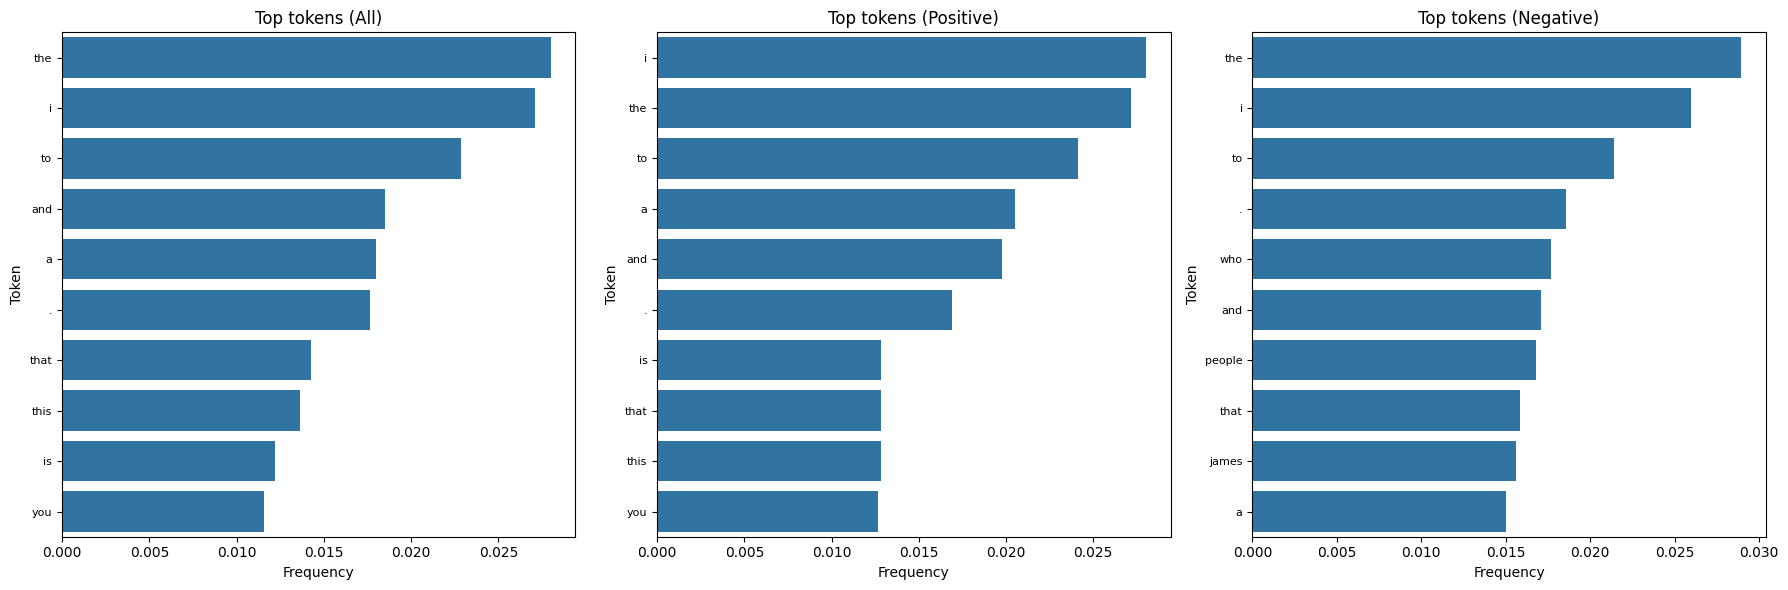

In [23]:
# Word-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_word')  # это количества

total_all = sum(freq_all.values())
top_all = [(token, count/total_all) for token, count in freq_all.most_common(10)]

total_pos = sum(freq_pos.values())
top_pos = [(token, count/total_pos) for token, count in freq_pos.most_common(10)]

total_neg = sum(freq_neg.values())
top_neg = [(token, count/total_neg) for token, count in freq_neg.most_common(10)]

freq_visualization(top_all, top_pos, top_neg)

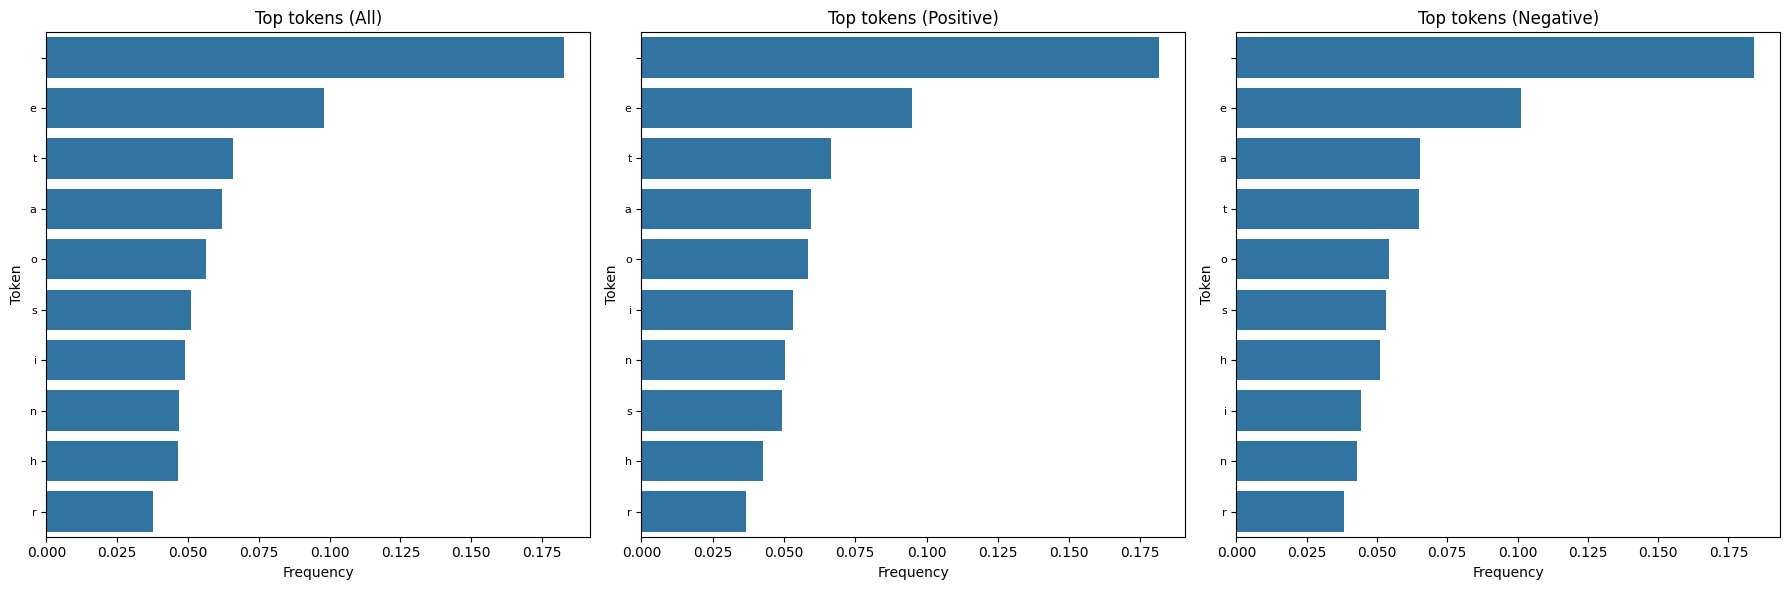

In [24]:
# Char-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_char')

total_all = sum(freq_all.values())
top_all = [(token, count/total_all) for token, count in freq_all.most_common(10)]

total_pos = sum(freq_pos.values())
top_pos = [(token, count/total_pos) for token, count in freq_pos.most_common(10)]

total_neg = sum(freq_neg.values())
top_neg = [(token, count/total_neg) for token, count in freq_neg.most_common(10)]

freq_visualization(top_all, top_pos, top_neg)

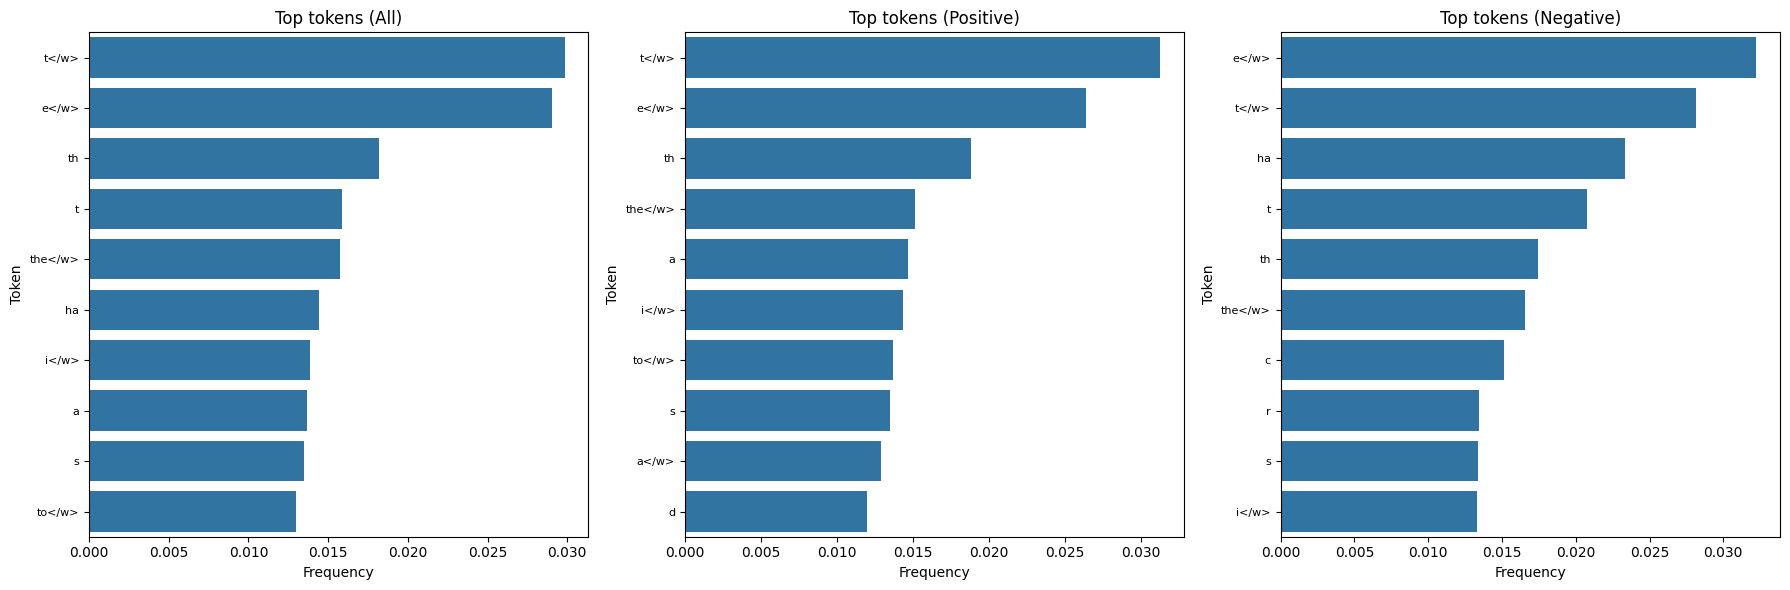

In [25]:
# BPE

freq_all, freq_pos, freq_neg = count_tokens('tokens_bpe')

total_all = sum(freq_all.values())
top_all = [(token, count/total_all) for token, count in freq_all.most_common(10)]

total_pos = sum(freq_pos.values())
top_pos = [(token, count/total_pos) for token, count in freq_pos.most_common(10)]

total_neg = sum(freq_neg.values())
top_neg = [(token, count/total_neg) for token, count in freq_neg.most_common(10)]

freq_visualization(top_all, top_pos, top_neg)

**ВАШИ ВЫВОДЫ**

- **Word-level**: самые частые токены (`the`, `to`, `I`, `a`, `and`, `is`, `it`, `you`) и знаки препинания. Видно, что между позитивнвым и негативным классами больше всего различий, нежели в других подходах.

- **Char-level**: самые частые токины (`e`, `t`, `a`, `o`, `i`, `n`, `s`, `r`). Они как будто вообще не информативны, в классах почти совпадают.

- **BPE**: самые частые токены (`th`, `the`, `in`, `er`, `an`, `re`, `ing`). Тут уже видно какие-то морфологические особенности английского (например, `ly` для наречий, `ed` для прошедшего времени). Но распределение токенов по классам также слабо отличается. 


***
Знать самые частые токены — это конечно хорошо, но кажется, что нам важнее знать те токены, у которых сильно **отличается частота в зависимости от класса**. Давайте для каждого вида токенизации найдем **топ 15** таких токенов.

In [26]:
# Word-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_word')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs = {}  # token : diff
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())

for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs[token] = abs(pos_rel - neg_rel)

top_diff_word = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_word:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: james | Разница: 0.01405
Токен: who | Разница: 0.01149
Токен: charles | Разница: 0.01129
Токен: people | Разница: 0.01091
Токен: hate | Разница: 0.01057
Токен: 👇 | Разница: 0.00647
Токен: bad | Разница: 0.00621
Токен: her | Разница: 0.00596
Токен: a | Разница: 0.00546
Токен: ' | Разница: 0.00543
Токен: him | Разница: 0.00519
Токен: already | Разница: 0.00465
Токен: " | Разница: 0.00448
Токен: hated | Разница: 0.00412
Токен: love | Разница: 0.00403


In [27]:
# Char-level

freq_all, freq_pos, freq_neg = count_tokens('tokens_char')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())

for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs[token] = abs(pos_rel - neg_rel)

top_diff_char = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_char:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: i | Разница: 0.00860
Токен: h | Разница: 0.00819
Токен: n | Разница: 0.00725
Токен: e | Разница: 0.00625
Токен: a | Разница: 0.00572
Токен: g | Разница: 0.00495
Токен: o | Разница: 0.00425
Токен: v | Разница: 0.00404
Токен: 
 | Разница: 0.00393
Токен: s | Разница: 0.00382
Токен: 👇 | Разница: 0.00305
Токен: c | Разница: 0.00295
Токен: k | Разница: 0.00286
Токен: J | Разница: 0.00283
Токен:   | Разница: 0.00255


In [28]:
# BPE

freq_all, freq_pos, freq_neg = count_tokens('tokens_bpe')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())

for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs[token] = abs(pos_rel - neg_rel)

top_diff_bpe = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:15]

for token, diff in top_diff_bpe:
    print(f"Токен: {token} | Разница: {diff:.5f}")

Токен: ha | Разница: 0.01643
Токен: t | Разница: 0.00888
Токен: james</w> | Разница: 0.00755
Токен: es</w> | Разница: 0.00678
Токен: who</w> | Разница: 0.00657
Токен: c | Разница: 0.00640
Токен: r | Разница: 0.00610
Токен: e</w> | Разница: 0.00590
Токен: people</w> | Разница: 0.00584
Токен: g | Разница: 0.00410
Токен: re | Разница: 0.00378
Токен: 👇</w> | Разница: 0.00374
Токен: ee | Разница: 0.00351
Токен: ba | Разница: 0.00336
Токен: l | Разница: 0.00335


**ВАША ПАРА СЛОВ ПРО ЭТО**

Word-токены лучше всего подходят для прямой интерпретации, BPE  для баланса между размером словаря и сохранением информации, а char-токены как будто вообще не сильно информативны.

### Создание признаков (1,5 pt)

Теперь, когда мы знаем частоты токенов, можно создавать признаки для классификации. Давайте сделаем **пять разных обучающих наборов** (учтите, что вам еще также менять и тест, поэтому лучше сделать функцию):
1. (1 - 3) присутствуют или нет **топ-10 слов по каждой токенизации отдельно**,
2. **объединенный топ** по всем токенизациям,
3. ваши признаки, которые вы считаете, что хорошо себя покажут.

То есть мы хотим превратить наши предложения в **таблицы единиц и нулей**: встречаются ли токены, или нет.

In [29]:
def one_tok_features(data, top_diff, column_name):
    new_data = pd.DataFrame({'label': data['label']})
    target_tokens = [token for token, diff in top_diff]
    
    for token in target_tokens:
        # создаём столбец: 1 если токен есть в списке токенов комментария, иначе 0
        new_data[token] = data[column_name].apply(lambda tokens_list: 1 if token in tokens_list else 0)
    
    return new_data

In [30]:
# Word-level

train_data_word_ohe = one_tok_features(train_data, top_diff_word, 'tokens_word')
test_data_word_ohe = one_tok_features(test_data, top_diff_word, 'tokens_word')

# Char-level

train_data_char_ohe = one_tok_features(train_data, top_diff_char, 'tokens_char')
test_data_char_ohe = one_tok_features(test_data, top_diff_char, 'tokens_char')

# BPE

train_data_bpe_ohe = one_tok_features(train_data, top_diff_bpe, 'tokens_bpe')
test_data_bpe_ohe = one_tok_features(test_data, top_diff_bpe, 'tokens_bpe')

In [31]:
def all_tok_features(data, top_diffs, column_names):
    
    new_data = pd.DataFrame({'label': data['label']})
    
    for col, diff_list in zip(column_names, top_diffs):
        tokens = [token for token, diff in diff_list]
        
        for token in tokens:
            feature_name = f"{col}_{token}"
            new_data[feature_name] = data[col].apply(lambda tokens_list: 1 if token in tokens_list else 0)
    
    return new_data

In [32]:
# All

train_data_all_ohe = all_tok_features(train_data,
                                      [top_diff_word, top_diff_char, top_diff_bpe],
                                      ['tokens_word', 'tokens_char', 'tokens_bpe'])
test_data_all_ohe = all_tok_features(test_data,
                                      [top_diff_word, top_diff_char, top_diff_bpe],
                                      ['tokens_word', 'tokens_char', 'tokens_bpe'])

In [33]:
def my_features(data):
    new_data = pd.DataFrame({'label': data['label']})
    
    target_tokens = [token for token, diff in top_diff_word]
    for token in target_tokens:
        new_data[token] = data['tokens_word'].apply(lambda x: 1 if token in x else 0)
    
    # дополнительные признаки
    new_data['comment_length'] = data['Comment'].str.len()             # длина текста
    new_data['excl_count'] = data['Comment'].str.count('!')           # восклицательные знаки
    new_data['quest_count'] = data['Comment'].str.count(r'\?')        # вопросительные знаки
    
    return new_data

небольшое пояснение: есть гипотеза, что длина текста может влиять на то, позитивный коммент или негативный, по медиане было видно, что позитивные тексты длиннее. восклицательные знаки могут влиять на эмоциональность, также как и вопросительные.

In [34]:
train_data_my_features = my_features(train_data)
test_data_my_features = my_features(test_data)

### Разделимость классов (1 pt)

Прежде чем одучать, давайте посмотрим на то, как **признаки классы разделяют**. Возможно, что-то совсем не работает)

Для этого воспользуемся уже известным нам `PCA` и визуализируем все в 2D.

In [35]:
def visualize_umap(df, title="UMAP"):
    X = df.drop('label', axis=1)
    y = df['label']

    pca = PCA(n_components=2, random_state=42)
    pca_data = pca.fit_transform(X)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=y, palette='coolwarm', alpha=0.6)
    plt.title(title)
    plt.legend(title='Sentiment', labels=['Negative', 'Positive'])
    plt.grid(True, alpha=0.3)
    plt.show()

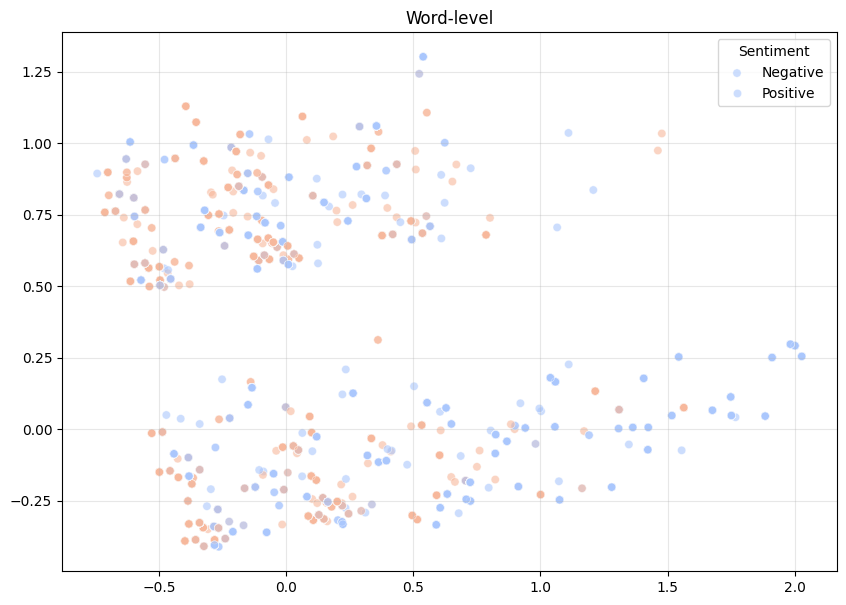

In [36]:
visualize_umap(train_data_word_ohe, "Word-level")

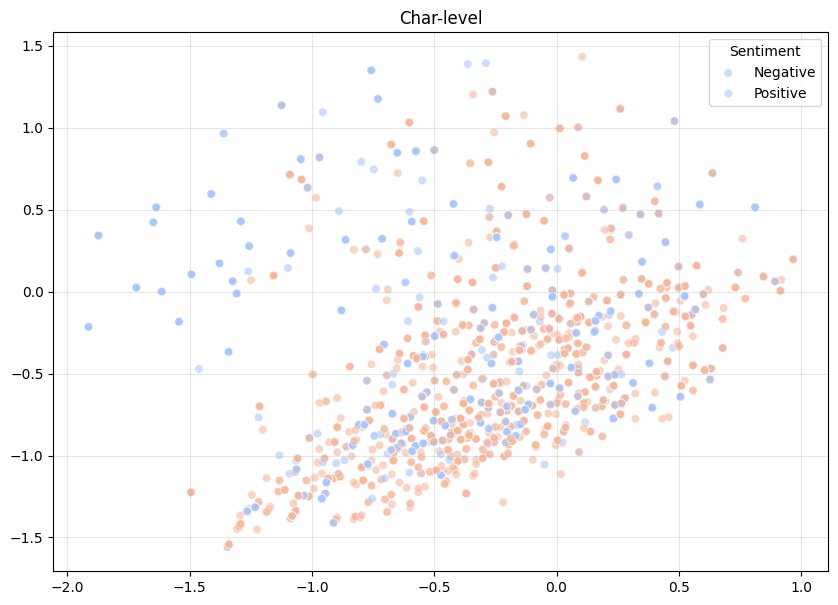

In [37]:
visualize_umap(train_data_char_ohe, "Char-level")

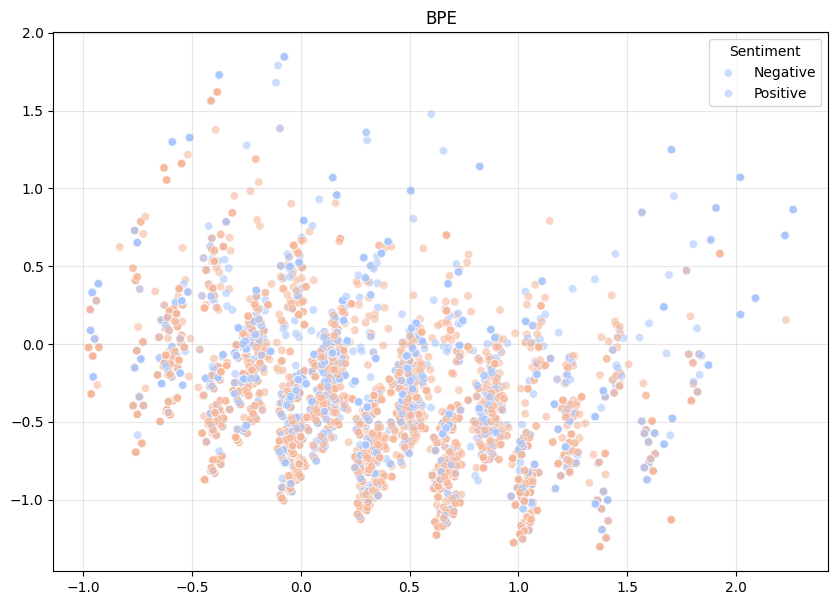

In [38]:
visualize_umap(train_data_bpe_ohe, "BPE")

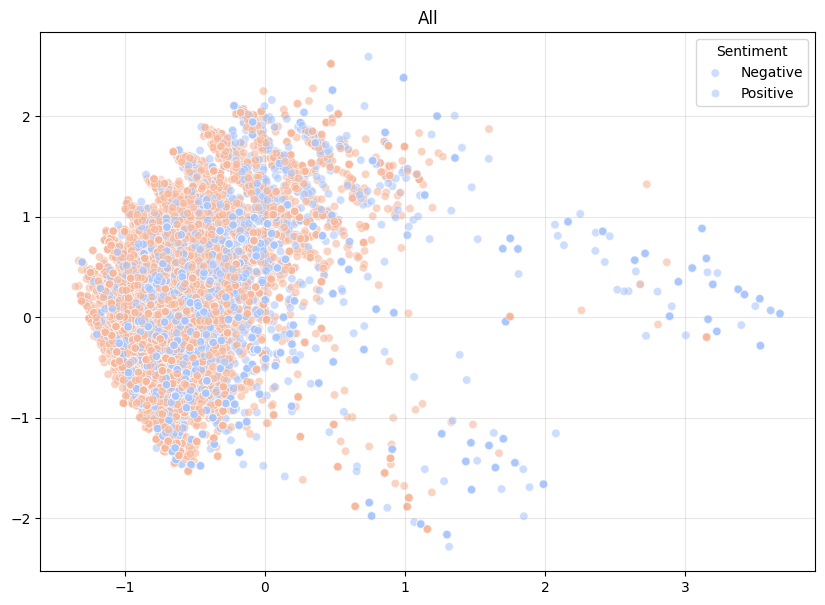

In [39]:
visualize_umap(train_data_all_ohe, "All")

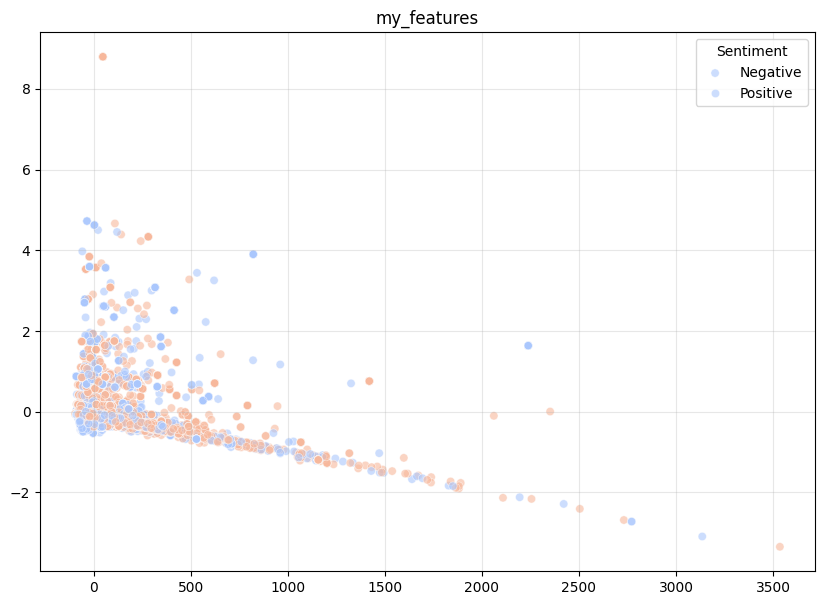

In [40]:
visualize_umap(train_data_my_features, "my_features")

**ВАШИ ВЫВОДЫ**

как таковых сильных куч не видно, видны какие-то тренды, но позитив и негавтив явно перемешаны. как предложено ниже, увеличу кол-во токенов в топе.

In [41]:
freq_all, freq_pos, freq_neg = count_tokens('tokens_word')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_word = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())
for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs_word[token] = abs(pos_rel - neg_rel)

# топ-50
sorted_diffs_word = []
for token, diff in diffs_word.items():
    sorted_diffs_word.append((diff, token))
sorted_diffs_word.sort(reverse=True)
top_diff_word_50 = [(token, diff) for diff, token in sorted_diffs_word[:50]]

In [42]:
freq_all, freq_pos, freq_neg = count_tokens('tokens_char')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_char = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())
for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs_char[token] = abs(pos_rel - neg_rel)

sorted_diffs_char = []
for token, diff in diffs_char.items():
    sorted_diffs_char.append((diff, token))
sorted_diffs_char.sort(reverse=True)
top_diff_char_50 = [(token, diff) for diff, token in sorted_diffs_char[:50]]

In [43]:
freq_all, freq_pos, freq_neg = count_tokens('tokens_bpe')

total_pos = sum(freq_pos.values())
total_neg = sum(freq_neg.values())

diffs_bpe = {}
all_unique_tokens = set(freq_pos.keys()) | set(freq_neg.keys())
for token in all_unique_tokens:
    pos_rel = freq_pos.get(token, 0) / total_pos
    neg_rel = freq_neg.get(token, 0) / total_neg
    diffs_bpe[token] = abs(pos_rel - neg_rel)

sorted_diffs_bpe = []
for token, diff in diffs_bpe.items():
    sorted_diffs_bpe.append((diff, token))
sorted_diffs_bpe.sort(reverse=True)
top_diff_bpe_50 = [(token, diff) for diff, token in sorted_diffs_bpe[:50]]

C:\Users\pochi\AppData\Local\Temp\ipykernel_45132\588273797.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_data[feature_name] = data[col].apply(lambda tokens_list: 1 if token in tokens_list else 0)


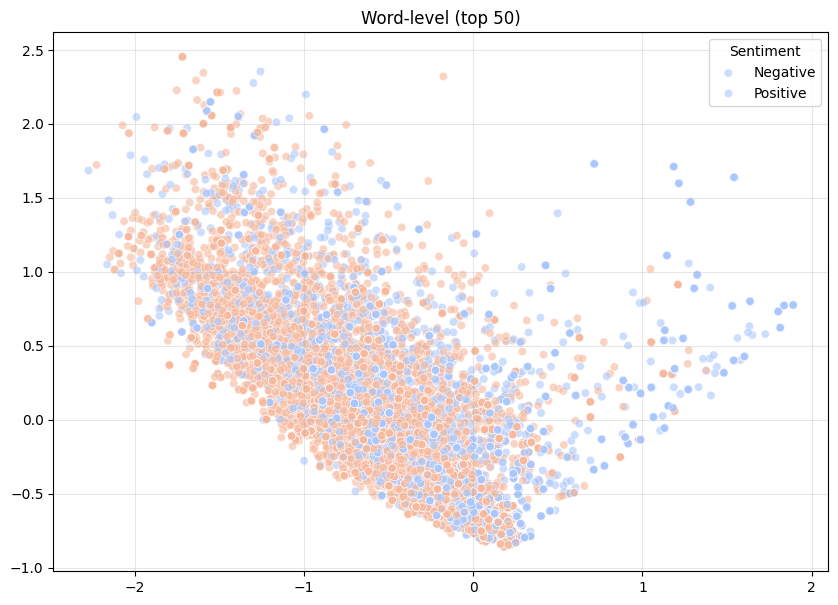

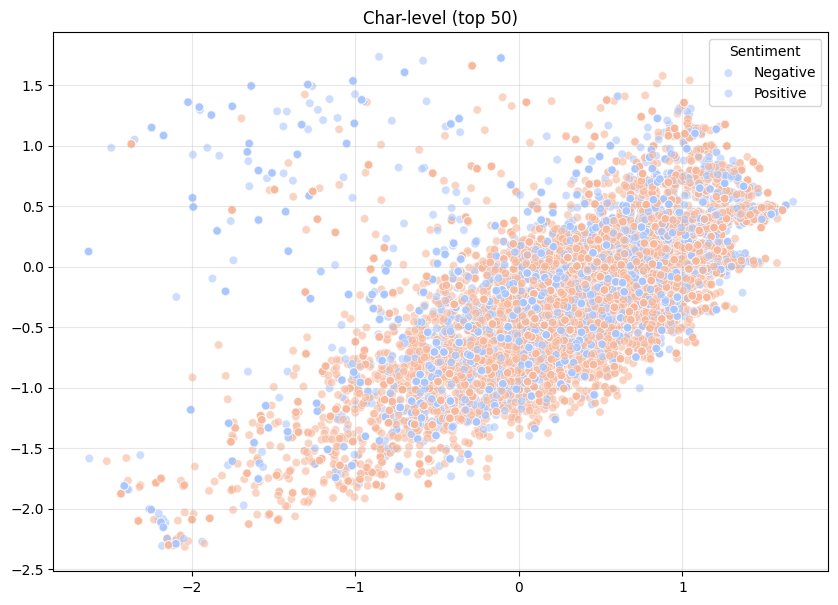

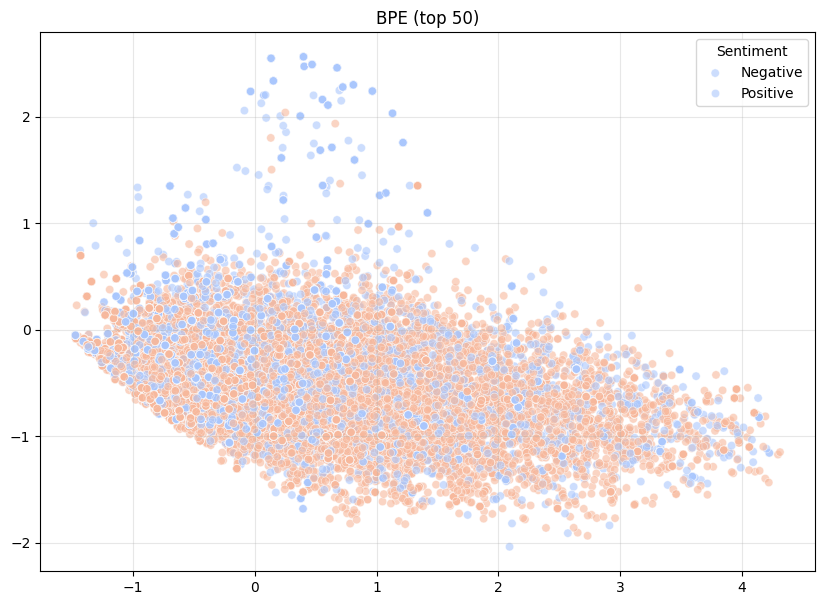

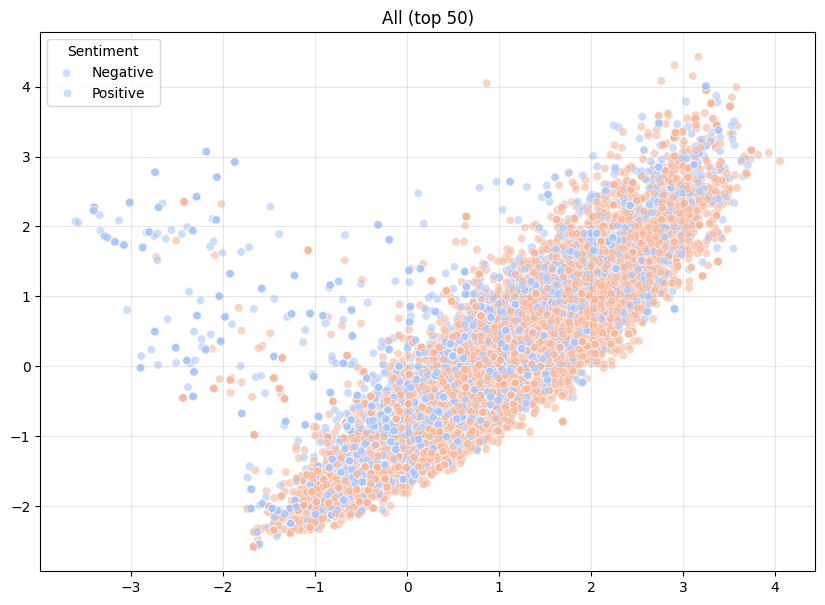

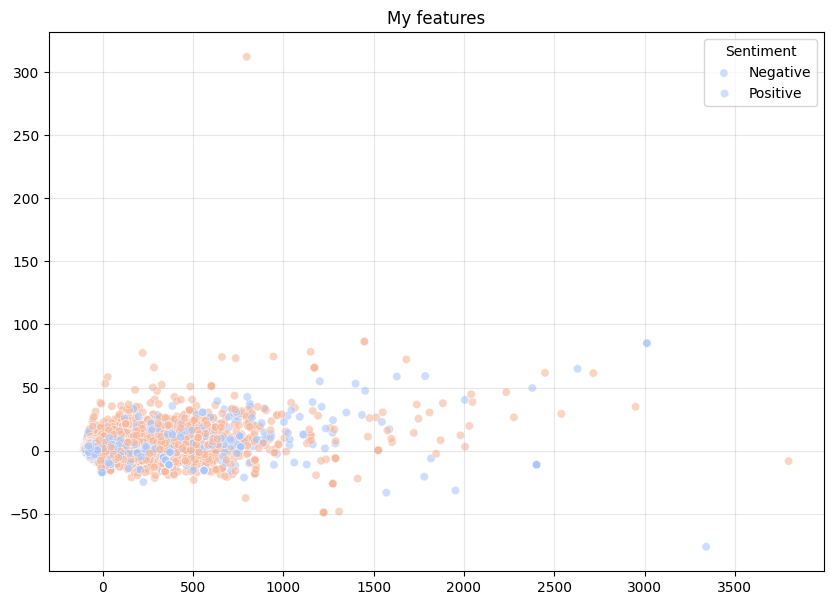

In [44]:
# Создаём признаки (50 токенов для каждого типа)
train_data_word_ohe_50 = one_tok_features(train_data, top_diff_word_50, 'tokens_word')
test_data_word_ohe_50 = one_tok_features(test_data, top_diff_word_50, 'tokens_word')

train_data_char_ohe_50 = one_tok_features(train_data, top_diff_char_50, 'tokens_char')
test_data_char_ohe_50 = one_tok_features(test_data, top_diff_char_50, 'tokens_char')

train_data_bpe_ohe_50 = one_tok_features(train_data, top_diff_bpe_50, 'tokens_bpe')
test_data_bpe_ohe_50 = one_tok_features(test_data, top_diff_bpe_50, 'tokens_bpe')

# Объединённые (150 признаков)
train_data_all_ohe_50 = all_tok_features(
    train_data,
    [top_diff_word_50, top_diff_char_50, top_diff_bpe_50],
    ['tokens_word', 'tokens_char', 'tokens_bpe']
)
test_data_all_ohe_50 = all_tok_features(
    test_data,
    [top_diff_word_50, top_diff_char_50, top_diff_bpe_50],
    ['tokens_word', 'tokens_char', 'tokens_bpe']
)

def my_features_50(data):
    new_data = pd.DataFrame({'label': data['label']})
    
    target_tokens_word = [token for token, diff in top_diff_word_50]
    for token in target_tokens_word:
        new_data[token] = data['tokens_word'].apply(lambda x: 1 if token in x else 0)
    
    # Дополнительные статистические признаки
    new_data['comment_length'] = data['Comment'].str.len()
    new_data['num_tokens_bpe'] = data['tokens_bpe'].apply(len)
    new_data['excl_count'] = data['Comment'].str.count('!')
    new_data['quest_count'] = data['Comment'].str.count(r'\?')
    
    return new_data

train_data_my_features_50 = my_features_50(train_data)
test_data_my_features_50 = my_features_50(test_data)

# PCA-визуализация
visualize_umap(train_data_word_ohe_50, "Word-level (top 50)")
visualize_umap(train_data_char_ohe_50, "Char-level (top 50)")
visualize_umap(train_data_bpe_ohe_50, "BPE (top 50)")
visualize_umap(train_data_all_ohe_50, "All (top 50)")
visualize_umap(train_data_my_features_50, "My features")

> Может быть слишком мало признаков? Вернитесь назад и попробуйте использовать больше признаков, что-то изменится?

даже при увелечении кол-ва токенов все равно явно по кучкам они не разбиваются. это ожидаемо, потому что PCA показывает общую вариативность данных, а не разделение классов. многие токены важные имеют низкую частоту, поэтому слабо влияют на направление максимальной дисперсии.

# Модели и интерпретация (1 pt)

Теперь перейдем к обучению, обучим простенькую люгистическую регрессию и посмотрим на метрики. Будем использовать `ROC-AUC`.

In [45]:
def train_and_predict(model, train_data, test_data, title):
    
    train_X = train_data.drop('label', axis=1)
    train_y = train_data['label']
    test_X = test_data.drop('label', axis=1)
    test_y = test_data['label']

    model.fit(train_X, train_y)
    
    for name, X, y in [
        ('train', train_X, train_y),
        ('test ', test_X, test_y)
    ]:
        proba = model.predict_proba(X)[:, 1]
        auc = roc_auc_score(y, proba)
        plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))
    
    plt.plot([0, 1], [0, 1], '--', color='black')
    plt.legend(fontsize='large')
    plt.title(title)
    plt.grid()
    
    test_accuracy = model.score(test_X, test_y)
    print(f"Model accuracy: {test_accuracy:.3f}")

Model accuracy: 0.742


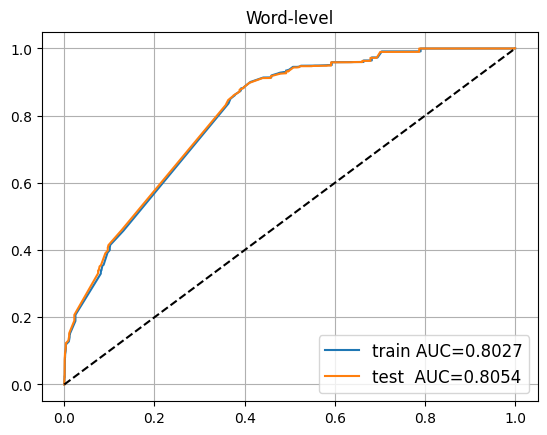

In [46]:
# Word-level

word_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(word_model, train_data_word_ohe, test_data_word_ohe, "Word-level")

Model accuracy: 0.732


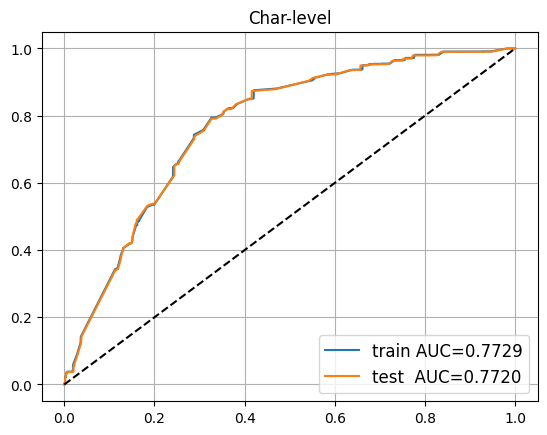

In [47]:
# Char-level

char_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(char_model, train_data_char_ohe, test_data_char_ohe, "Char-level")

Model accuracy: 0.698


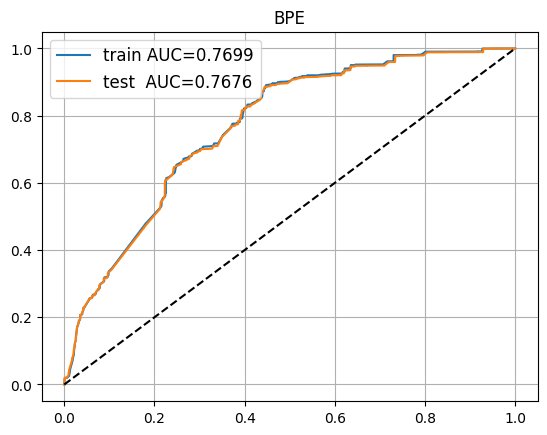

In [48]:
# BPE

bpe_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(bpe_model, train_data_bpe_ohe, test_data_bpe_ohe, "BPE")

Model accuracy: 0.789


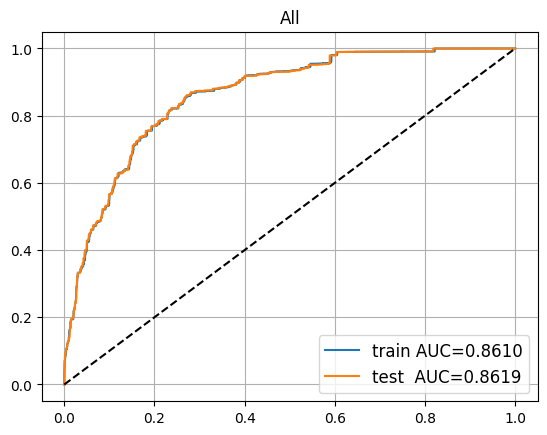

In [49]:
# All

all_model = LogisticRegression() # можно поиграться с параметром C
train_and_predict(all_model, train_data_all_ohe, test_data_all_ohe, "All")

c:\Users\pochi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model accuracy: 0.778


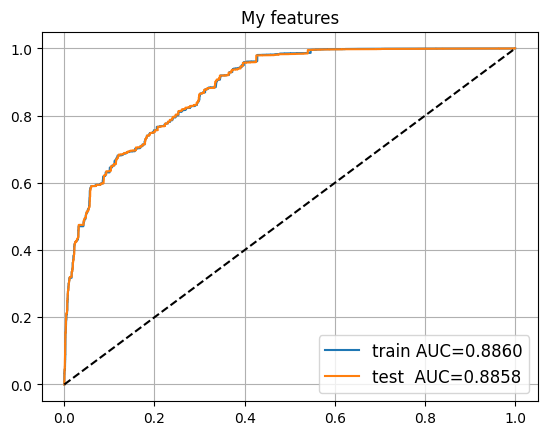

In [50]:
# обучение на ваших признаках

my_model = LogisticRegression(max_iter=1000)
train_and_predict(my_model, train_data_my_features_50, test_data_my_features_50, "My features")

**ВАША ИТОГОВАЯ ЦЕЛЬ — ПОБИТЬ ПОРОГ В `0.8 accuracy`**

Model accuracy: 0.862


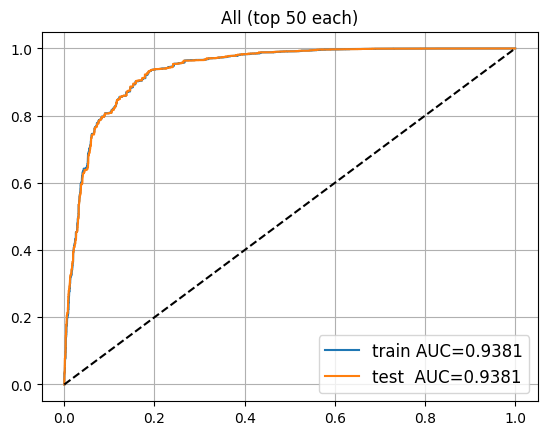

In [51]:
all_model_50 = LogisticRegression(max_iter=1000)
train_and_predict(all_model_50, train_data_all_ohe_50, test_data_all_ohe_50, "All (top 50 each)")

**ВАШИ ИТОГОВЫЕ ВЫВОДЫ ПО ВСЕЙ РАБОТЕ**

как по мне, самым крутым способом разделения для этой задачи оказался word. он дает наилучшие показатели по сравнению с остальными. а то, что словарь получился самым большим в этой задаче не мешает, все равно все относительно быстро обучается. в итоге accuracy 0.8 мне удалось побить просто топ 50 всех токенов. наверное, таким образом, модель учитывает больше синтаксических закономерностей. можно сделать вывод, что в задачах токенизации нужно использовать несколько признаков и брать из них самые "выгодные", которые сильнее всего разделяют классы.